In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# load file
# =========================
file_path = "training_results_history.xlsx"
df = pd.read_excel(file_path)

# =========================
# clean data
# =========================
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

numeric_cols = ["epoch", "loss", "precision", "recall", "f1", "iou"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# remove exact duplicate rows
df = df.drop_duplicates()

# sort by time so plots follow experiment order
df = df.sort_values("timestamp").reset_index(drop=True)

# shorter label for plotting
df["label"] = [f"{i+1}. {name}" for i, name in enumerate(df["run_name"])]

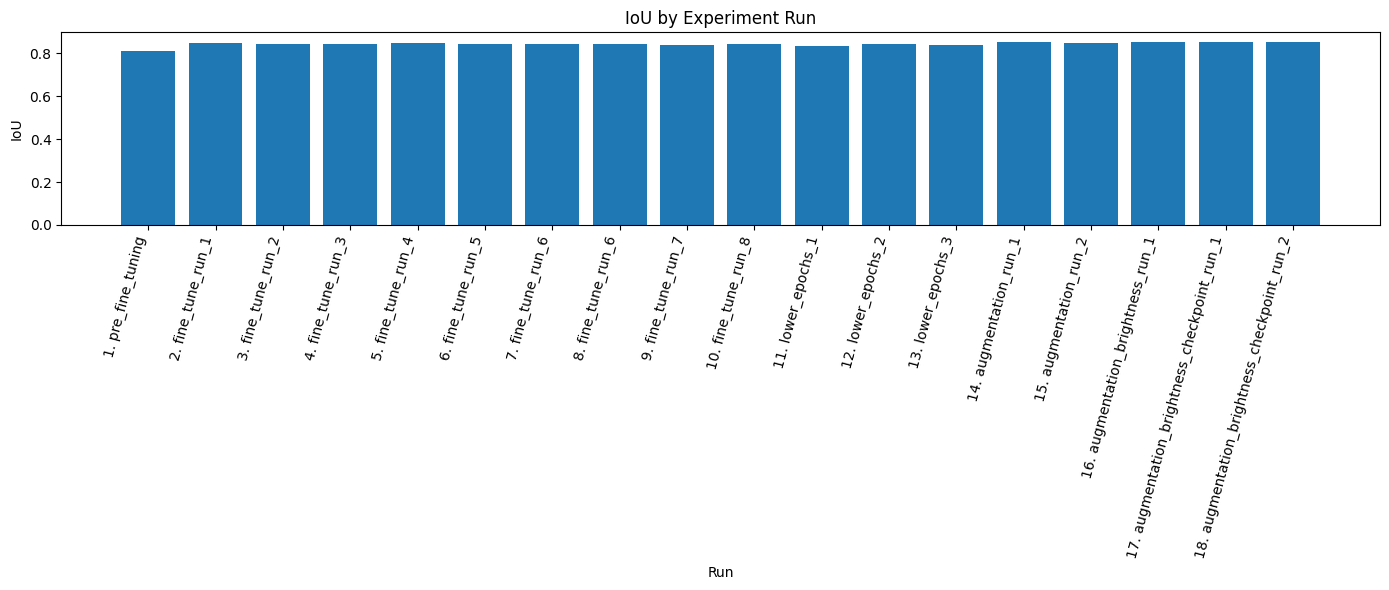

In [2]:
plt.figure(figsize=(14, 6))
plt.bar(df["label"], df["iou"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("IoU")
plt.xlabel("Run")
plt.title("IoU by Experiment Run")
plt.tight_layout()
plt.show()

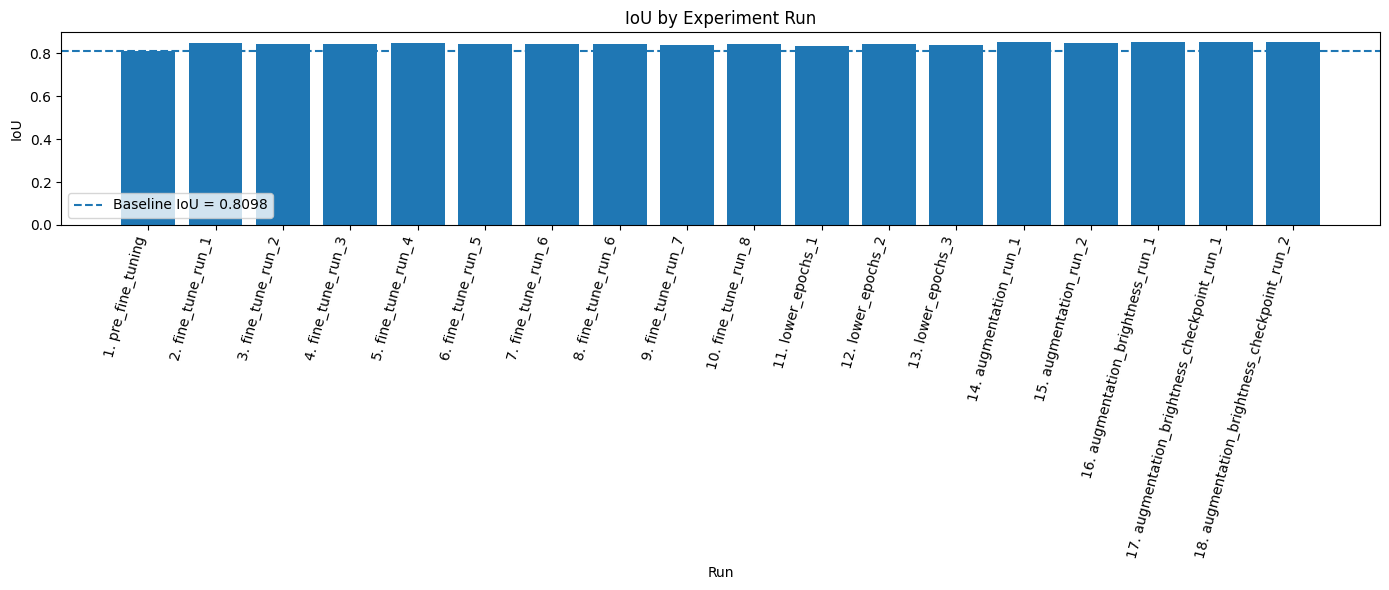

In [3]:
baseline_iou = df.loc[df["run_name"] == "pre_fine_tuning", "iou"].iloc[0]

plt.figure(figsize=(14, 6))
plt.bar(df["label"], df["iou"])
plt.axhline(baseline_iou, linestyle="--", label=f"Baseline IoU = {baseline_iou:.4f}")
plt.xticks(rotation=75, ha="right")
plt.ylabel("IoU")
plt.xlabel("Run")
plt.title("IoU by Experiment Run")
plt.legend()
plt.tight_layout()
plt.show()

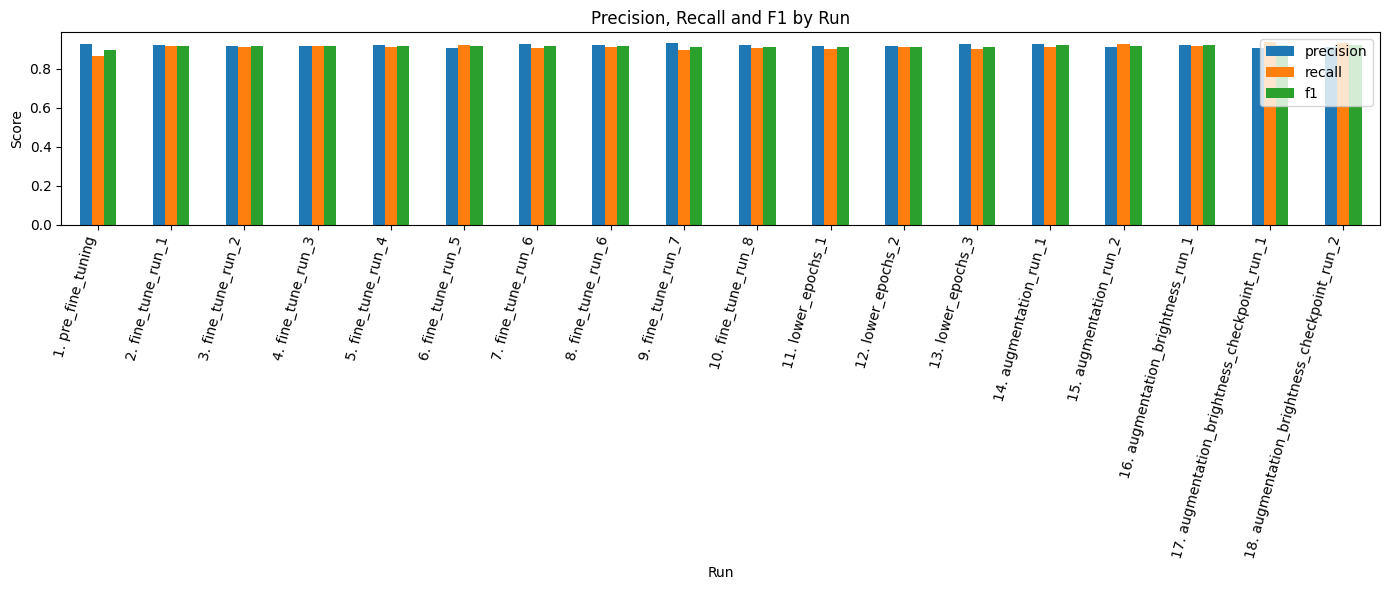

In [4]:
metrics_df = df[["label", "precision", "recall", "f1"]].set_index("label")

metrics_df.plot(kind="bar", figsize=(14, 6))
plt.ylabel("Score")
plt.xlabel("Run")
plt.title("Precision, Recall and F1 by Run")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

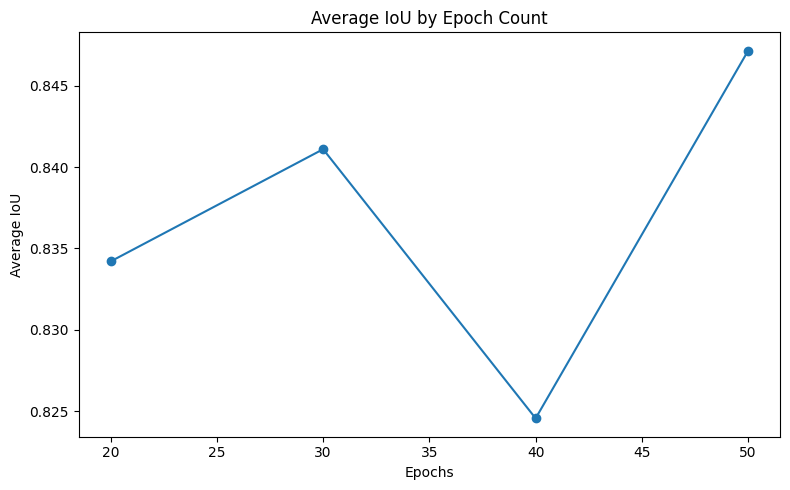

In [5]:
epoch_summary = df.groupby("epoch", as_index=False)["iou"].mean()

plt.figure(figsize=(8, 5))
plt.plot(epoch_summary["epoch"], epoch_summary["iou"], marker="o")
plt.xlabel("Epochs")
plt.ylabel("Average IoU")
plt.title("Average IoU by Epoch Count")
plt.tight_layout()
plt.show()

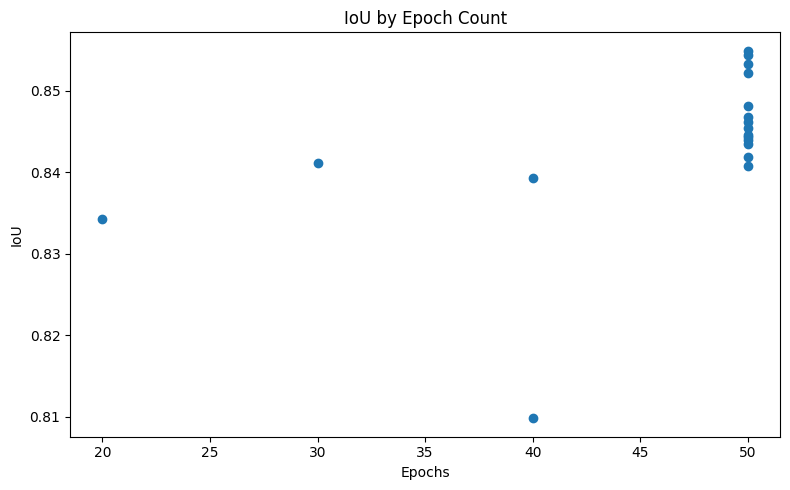

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(df["epoch"], df["iou"])
plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.title("IoU by Epoch Count")
plt.tight_layout()
plt.show()

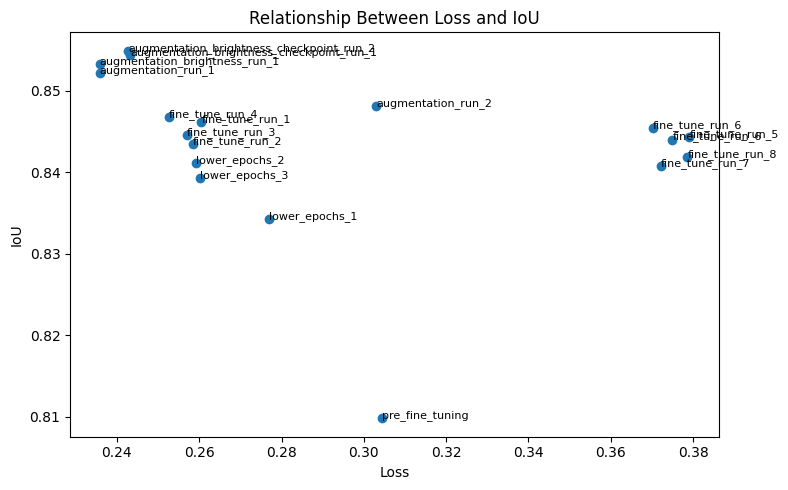

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(df["loss"], df["iou"])

for _, row in df.iterrows():
    plt.annotate(row["run_name"], (row["loss"], row["iou"]), fontsize=8)

plt.xlabel("Loss")
plt.ylabel("IoU")
plt.title("Relationship Between Loss and IoU")
plt.tight_layout()
plt.show()

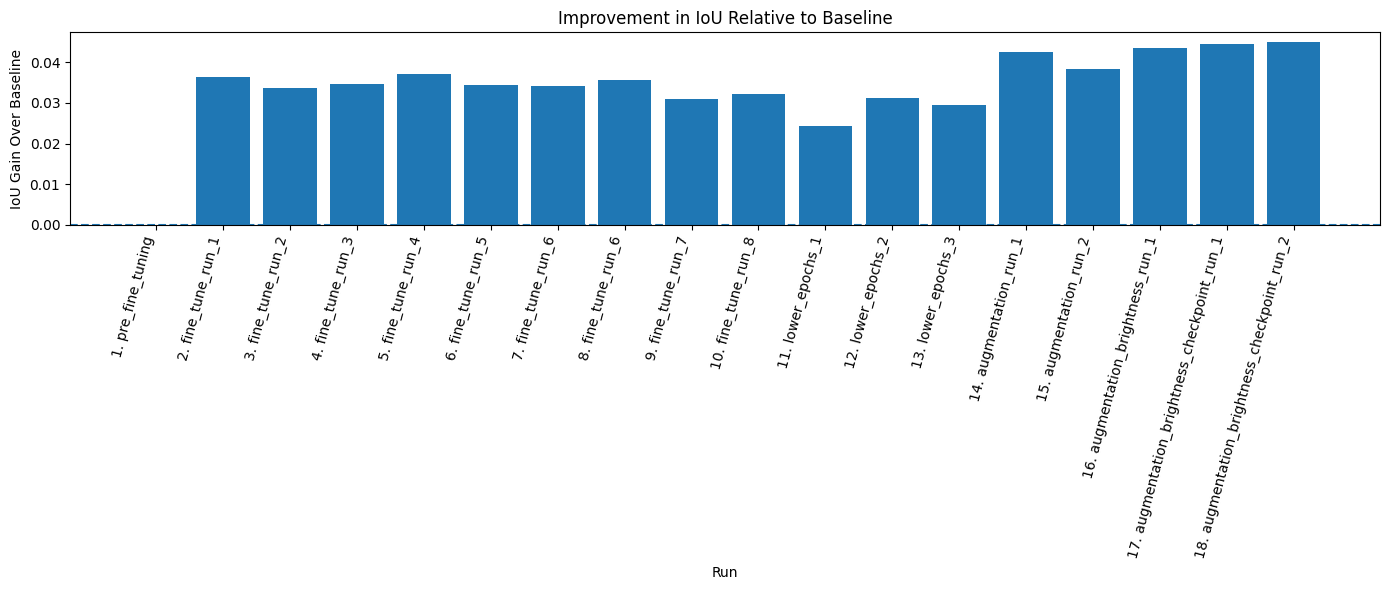

In [8]:
baseline_iou = df.loc[df["run_name"] == "pre_fine_tuning", "iou"].iloc[0]
df["iou_gain"] = df["iou"] - baseline_iou

plt.figure(figsize=(14, 6))
plt.bar(df["label"], df["iou_gain"])
plt.axhline(0, linestyle="--")
plt.xticks(rotation=75, ha="right")
plt.ylabel("IoU Gain Over Baseline")
plt.xlabel("Run")
plt.title("Improvement in IoU Relative to Baseline")
plt.tight_layout()
plt.show()

In [9]:
def classify_run(row):
    note = str(row["notes"]).lower()
    name = str(row["run_name"]).lower()

    if "baseline" in note or "pre_fine_tuning" in name:
        return "baseline"
    elif "20 epochs" in note or "30 epochs" in note or "40 epochs" in note or "lower_epochs" in name:
        return "epoch study"
    elif "brightness" in note:
        return "augmentation + brightness"
    elif "flip + rotate" in note:
        return "augmentation"
    elif "tversky" in note or "bce and dice" in note:
        return "loss function study"
    else:
        return "fine-tuning"

df["group"] = df.apply(classify_run, axis=1)

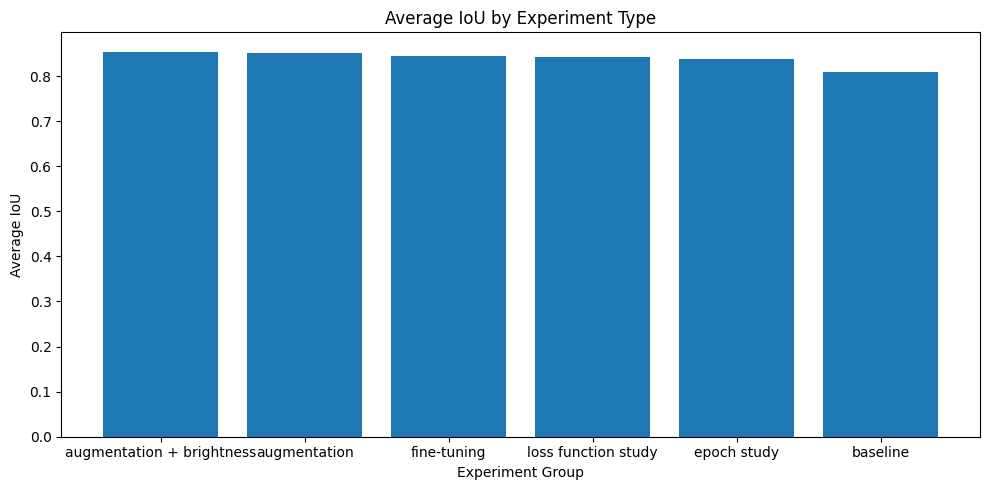

In [10]:
group_summary = df.groupby("group", as_index=False)["iou"].mean().sort_values("iou", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(group_summary["group"], group_summary["iou"])
plt.ylabel("Average IoU")
plt.xlabel("Experiment Group")
plt.title("Average IoU by Experiment Type")
plt.tight_layout()
plt.show()

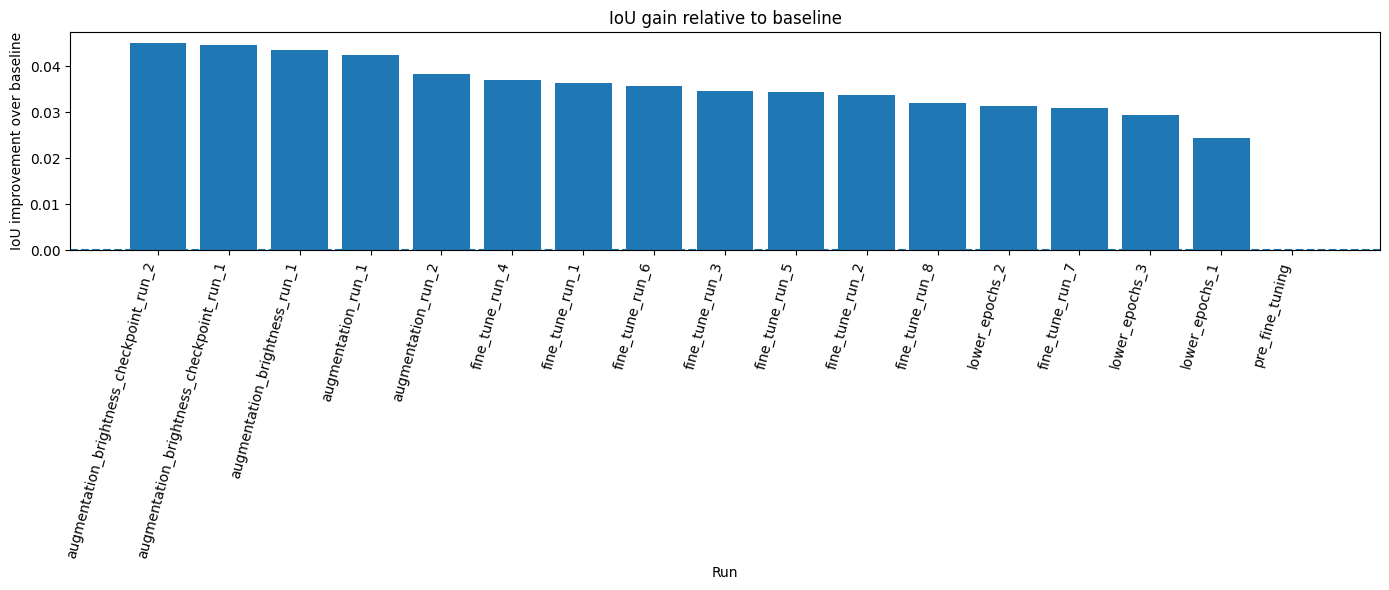

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "training_results_history.xlsx"
df = pd.read_excel(file_path).drop_duplicates()

baseline_iou = df.loc[df["run_name"] == "pre_fine_tuning", "iou"].iloc[0]
df["iou_gain"] = df["iou"] - baseline_iou

df_sorted = df.sort_values("iou_gain", ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(df_sorted["run_name"], df_sorted["iou_gain"])
plt.axhline(0, linestyle="--")
plt.xticks(rotation=75, ha="right")
plt.ylabel("IoU improvement over baseline")
plt.xlabel("Run")
plt.title("IoU gain relative to baseline")
plt.tight_layout()
plt.show()

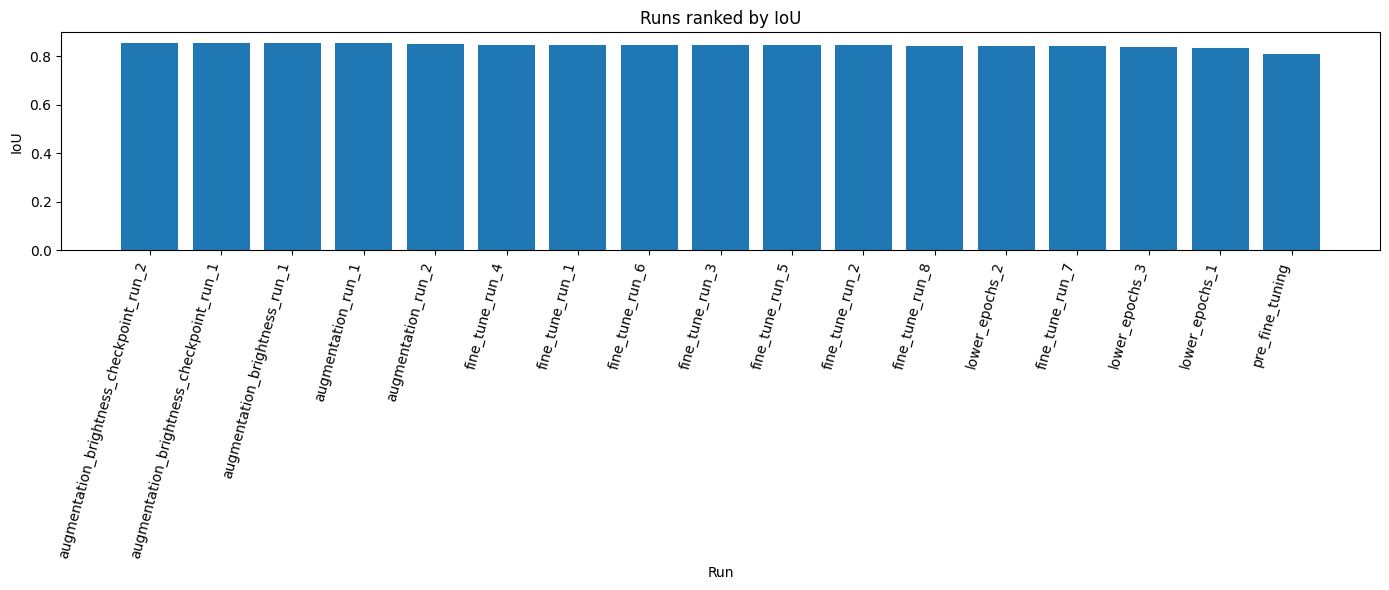

In [13]:
df_sorted = df.sort_values("iou", ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(df_sorted["run_name"], df_sorted["iou"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("IoU")
plt.xlabel("Run")
plt.title("Runs ranked by IoU")
plt.tight_layout()
plt.show()

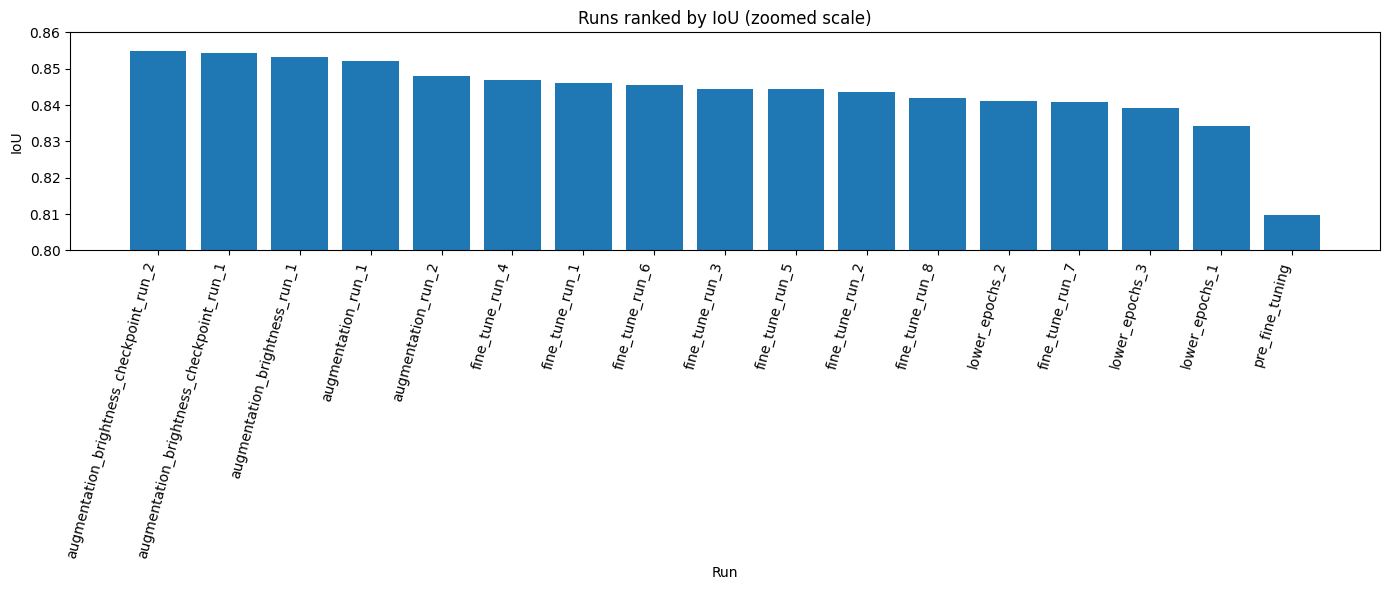

In [14]:
plt.figure(figsize=(14, 6))
plt.bar(df_sorted["run_name"], df_sorted["iou"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("IoU")
plt.xlabel("Run")
plt.title("Runs ranked by IoU (zoomed scale)")
plt.ylim(0.80, 0.86)
plt.tight_layout()
plt.show()

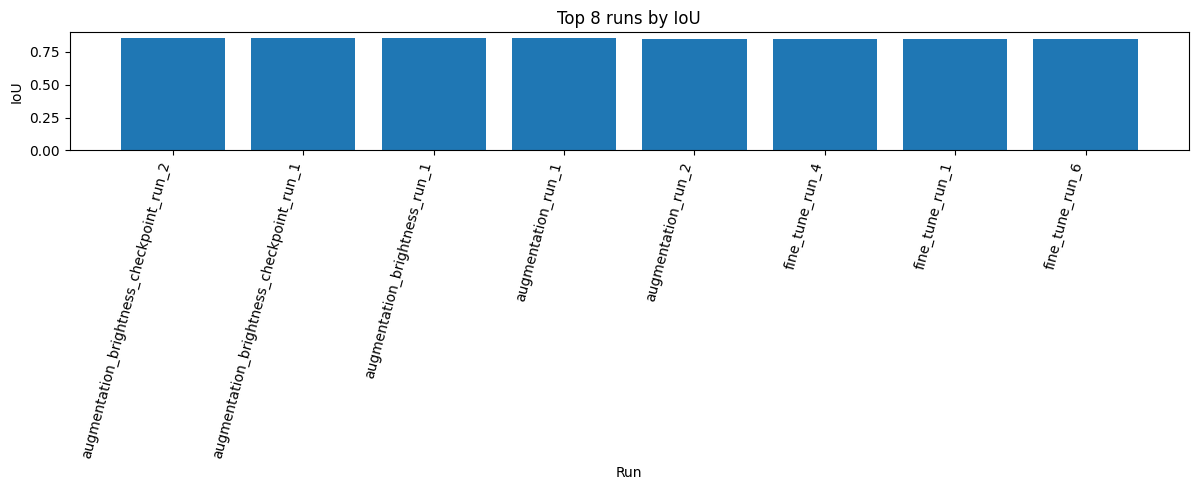

In [15]:
top_runs = df.sort_values("iou", ascending=False).head(8)

plt.figure(figsize=(12, 5))
plt.bar(top_runs["run_name"], top_runs["iou"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("IoU")
plt.xlabel("Run")
plt.title("Top 8 runs by IoU")
plt.tight_layout()
plt.show()

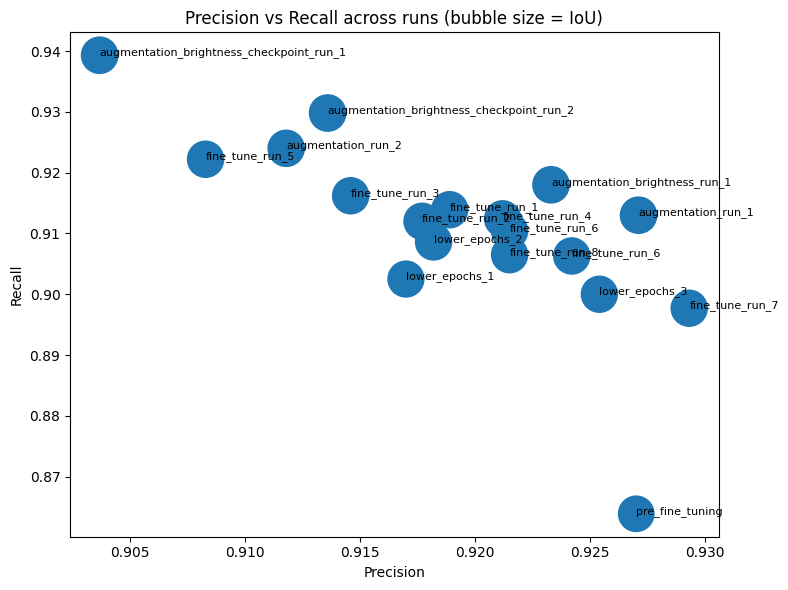

In [16]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df["precision"], df["recall"], s=df["iou"] * 800)

for _, row in df.iterrows():
    plt.annotate(row["run_name"], (row["precision"], row["recall"]), fontsize=8)

plt.xlabel("Precision")
plt.ylabel("Recall")
plt.title("Precision vs Recall across runs (bubble size = IoU)")
plt.tight_layout()
plt.show()

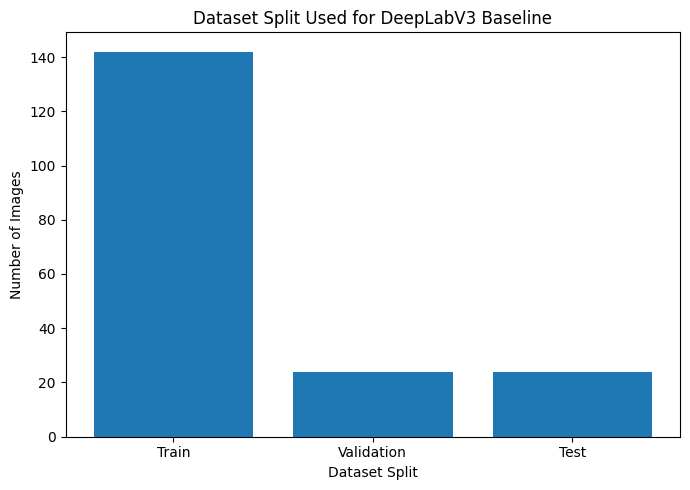

In [17]:
import matplotlib.pyplot as plt

splits = ["Train", "Validation", "Test"]
counts = [142, 24, 24]

plt.figure(figsize=(7, 5))
plt.bar(splits, counts)
plt.ylabel("Number of Images")
plt.xlabel("Dataset Split")
plt.title("Dataset Split Used for DeepLabV3 Baseline")
plt.tight_layout()
plt.show()

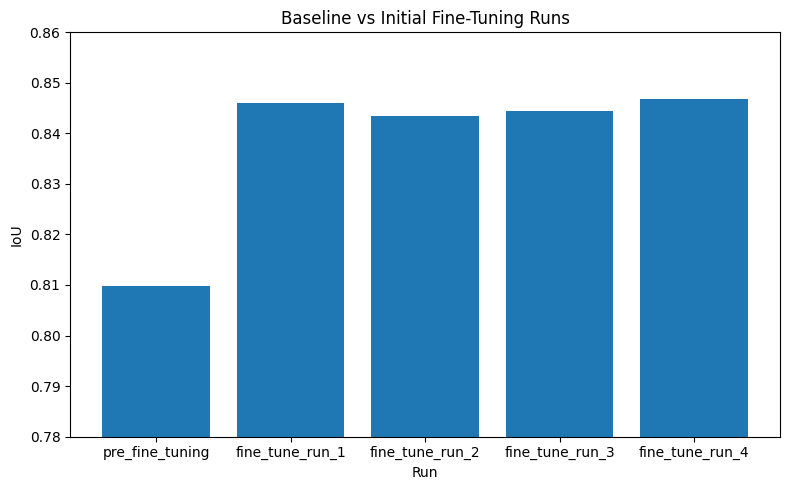

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "training_results_history.xlsx"
df = pd.read_excel(file_path)

# keep only the baseline and first fine-tuning runs
runs_to_plot = [
    "pre_fine_tuning",
    "fine_tune_run_1",
    "fine_tune_run_2",
    "fine_tune_run_3",
    "fine_tune_run_4",
]

plot_df = df[df["run_name"].isin(runs_to_plot)].copy()

# keep the first instance if there are duplicates elsewhere
plot_df = plot_df.drop_duplicates(subset=["run_name"], keep="first")

# order the runs properly
plot_df["run_name"] = pd.Categorical(
    plot_df["run_name"],
    categories=runs_to_plot,
    ordered=True
)
plot_df = plot_df.sort_values("run_name")

plt.figure(figsize=(8, 5))
plt.bar(plot_df["run_name"], plot_df["iou"])
plt.ylabel("IoU")
plt.xlabel("Run")
plt.title("Baseline vs Initial Fine-Tuning Runs")
plt.ylim(0.78, 0.86)
plt.tight_layout()
plt.show()

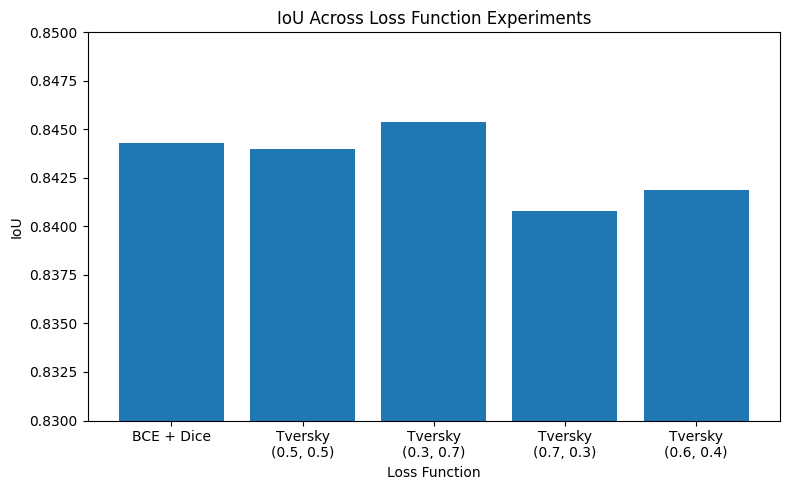

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "training_results_history.xlsx"
df = pd.read_excel(file_path)

# pick only the loss-function runs
plot_df = df.iloc[5:10].copy()

labels = [
    "BCE + Dice",
    "Tversky\n(0.5, 0.5)",
    "Tversky\n(0.3, 0.7)",
    "Tversky\n(0.7, 0.3)",
    "Tversky\n(0.6, 0.4)",
]

plot_df["label"] = labels

plt.figure(figsize=(8, 5))
plt.bar(plot_df["label"], plot_df["iou"])
plt.ylabel("IoU")
plt.xlabel("Loss Function")
plt.title("IoU Across Loss Function Experiments")
plt.ylim(0.83, 0.85)
plt.tight_layout()
plt.show()

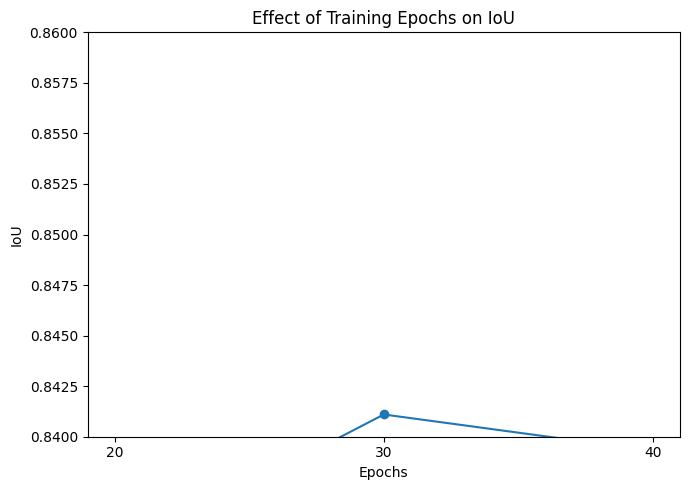

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "training_results_history.xlsx"
df = pd.read_excel(file_path)

# epoch testing runs
runs_to_plot = ["lower_epochs_1", "lower_epochs_2", "lower_epochs_3"]
plot_df = df[df["run_name"].isin(runs_to_plot)].copy()

# map runs to actual epoch values
epoch_map = {
    "lower_epochs_1": 20,
    "lower_epochs_2": 30,
    "lower_epochs_3": 40,
}

plot_df["epochs"] = plot_df["run_name"].map(epoch_map)
plot_df = plot_df.sort_values("epochs")

plt.figure(figsize=(7, 5))
plt.plot(plot_df["epochs"], plot_df["iou"], marker="o")
plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.title("Effect of Training Epochs on IoU")
plt.xticks([20, 30, 40])
plt.ylim(0.84, 0.86)
plt.tight_layout()
plt.show()

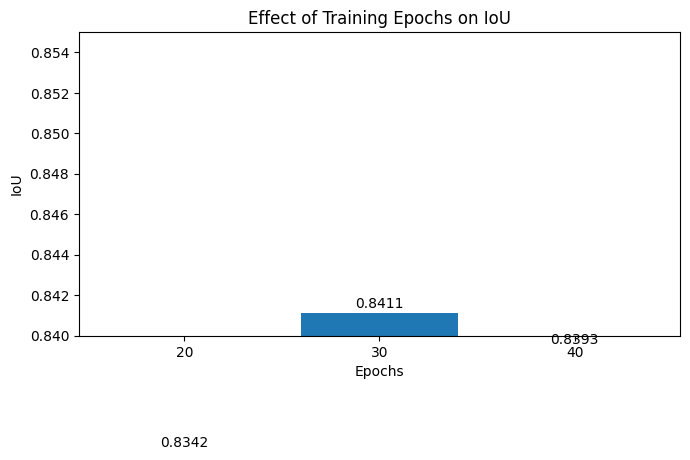

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "training_results_history.xlsx"
df = pd.read_excel(file_path)

runs_to_plot = ["lower_epochs_1", "lower_epochs_2", "lower_epochs_3"]
plot_df = df[df["run_name"].isin(runs_to_plot)].copy()

epoch_map = {
    "lower_epochs_1": 20,
    "lower_epochs_2": 30,
    "lower_epochs_3": 40,
}

plot_df["epochs"] = plot_df["run_name"].map(epoch_map)
plot_df = plot_df.sort_values("epochs")

plt.figure(figsize=(7, 5))
plt.bar(plot_df["epochs"].astype(str), plot_df["iou"])

for _, row in plot_df.iterrows():
    plt.text(
        x=str(row["epochs"]),
        y=row["iou"] + 0.0003,
        s=f"{row['iou']:.4f}",
        ha="center"
    )

plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.title("Effect of Training Epochs on IoU")
plt.ylim(0.84, 0.855)
plt.tight_layout()
plt.show()

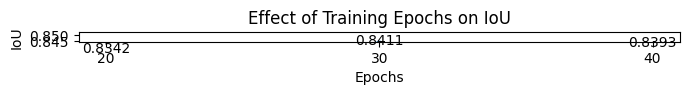

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "training_results_history.xlsx"
df = pd.read_excel(file_path)

runs_to_plot = ["lower_epochs_1", "lower_epochs_2", "lower_epochs_3"]
plot_df = df[df["run_name"].isin(runs_to_plot)].copy()

epoch_map = {
    "lower_epochs_1": 20,
    "lower_epochs_2": 30,
    "lower_epochs_3": 40,
}

plot_df["epochs"] = plot_df["run_name"].map(epoch_map)
plot_df = plot_df.sort_values("epochs")

plt.figure(figsize=(7, 5))
plt.plot(plot_df["epochs"], plot_df["iou"], marker="o")

for _, row in plot_df.iterrows():
    plt.text(row["epochs"], row["iou"] + 0.0002, f"{row['iou']:.4f}", ha="center")

plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.title("Effect of Training Epochs on IoU")
plt.xticks([20, 30, 40])
plt.ylim(0.844, 0.8525)
plt.tight_layout()
plt.show()

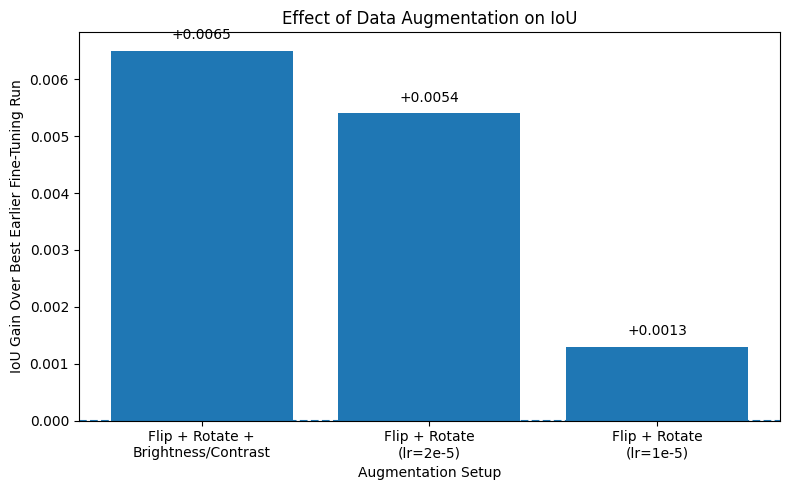

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "training_results_history.xlsx"
df = pd.read_excel(file_path).drop_duplicates()

runs_to_plot = [
    "augmentation_run_1",
    "augmentation_run_2",
    "augmentation_brightness_run_1",
]

plot_df = df[df["run_name"].isin(runs_to_plot)].copy()

label_map = {
    "augmentation_run_1": "Flip + Rotate\n(lr=2e-5)",
    "augmentation_run_2": "Flip + Rotate\n(lr=1e-5)",
    "augmentation_brightness_run_1": "Flip + Rotate +\nBrightness/Contrast",
}

plot_df["label"] = plot_df["run_name"].map(label_map)

# best earlier non-augmentation run from the fine-tuning stage
best_previous_iou = 0.8468
plot_df["iou_gain"] = plot_df["iou"] - best_previous_iou

plot_df = plot_df.sort_values("iou_gain", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["label"], plot_df["iou_gain"])

for _, row in plot_df.iterrows():
    plt.text(
        row["label"],
        row["iou_gain"] + 0.0002,
        f"{row['iou_gain']:+.4f}",
        ha="center"
    )

plt.axhline(0, linestyle="--")
plt.ylabel("IoU Gain Over Best Earlier Fine-Tuning Run")
plt.xlabel("Augmentation Setup")
plt.title("Effect of Data Augmentation on IoU")
plt.tight_layout()
plt.show()

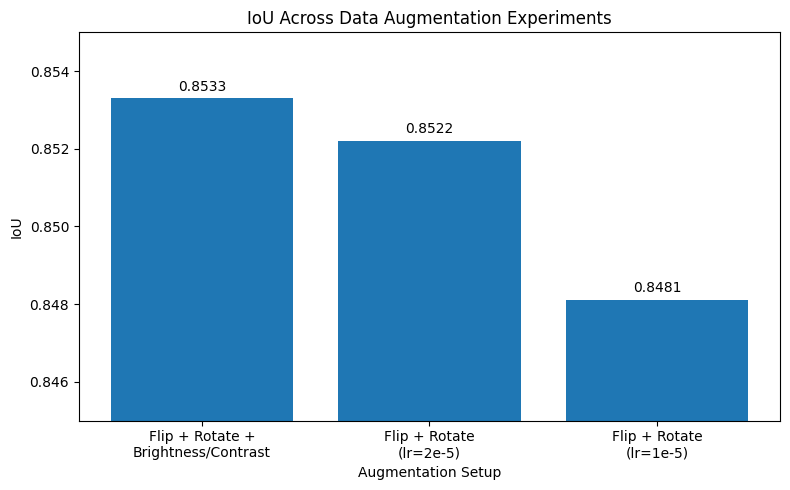

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "training_results_history.xlsx"
df = pd.read_excel(file_path).drop_duplicates()

runs_to_plot = [
    "augmentation_run_1",
    "augmentation_run_2",
    "augmentation_brightness_run_1",
]

plot_df = df[df["run_name"].isin(runs_to_plot)].copy()

label_map = {
    "augmentation_run_1": "Flip + Rotate\n(lr=2e-5)",
    "augmentation_run_2": "Flip + Rotate\n(lr=1e-5)",
    "augmentation_brightness_run_1": "Flip + Rotate +\nBrightness/Contrast",
}

plot_df["label"] = plot_df["run_name"].map(label_map)
plot_df = plot_df.sort_values("iou", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["label"], plot_df["iou"])

for _, row in plot_df.iterrows():
    plt.text(
        row["label"],
        row["iou"] + 0.0002,
        f"{row['iou']:.4f}",
        ha="center"
    )

plt.ylabel("IoU")
plt.xlabel("Augmentation Setup")
plt.title("IoU Across Data Augmentation Experiments")
plt.ylim(0.845, 0.855)
plt.tight_layout()
plt.show()

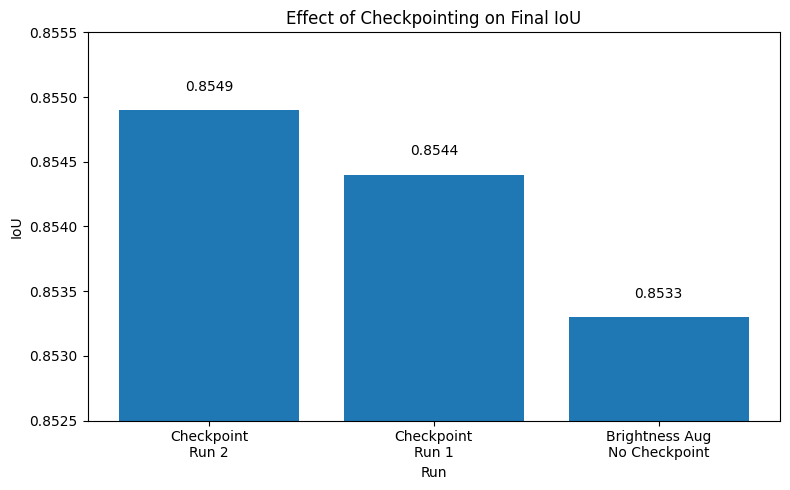

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "training_results_history.xlsx"
df = pd.read_excel(file_path).drop_duplicates()

runs_to_plot = [
    "augmentation_brightness_run_1",
    "augmentation_brightness_checkpoint_run_1",
    "augmentation_brightness_checkpoint_run_2",
]

plot_df = df[df["run_name"].isin(runs_to_plot)].copy()

label_map = {
    "augmentation_brightness_run_1": "Brightness Aug\nNo Checkpoint",
    "augmentation_brightness_checkpoint_run_1": "Checkpoint\nRun 1",
    "augmentation_brightness_checkpoint_run_2": "Checkpoint\nRun 2",
}

plot_df["label"] = plot_df["run_name"].map(label_map)
plot_df = plot_df.sort_values("iou", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["label"], plot_df["iou"])

for _, row in plot_df.iterrows():
    plt.text(
        row["label"],
        row["iou"] + 0.00015,
        f"{row['iou']:.4f}",
        ha="center"
    )

plt.ylabel("IoU")
plt.xlabel("Run")
plt.title("Effect of Checkpointing on Final IoU")
plt.ylim(0.8525, 0.8555)
plt.tight_layout()
plt.show()

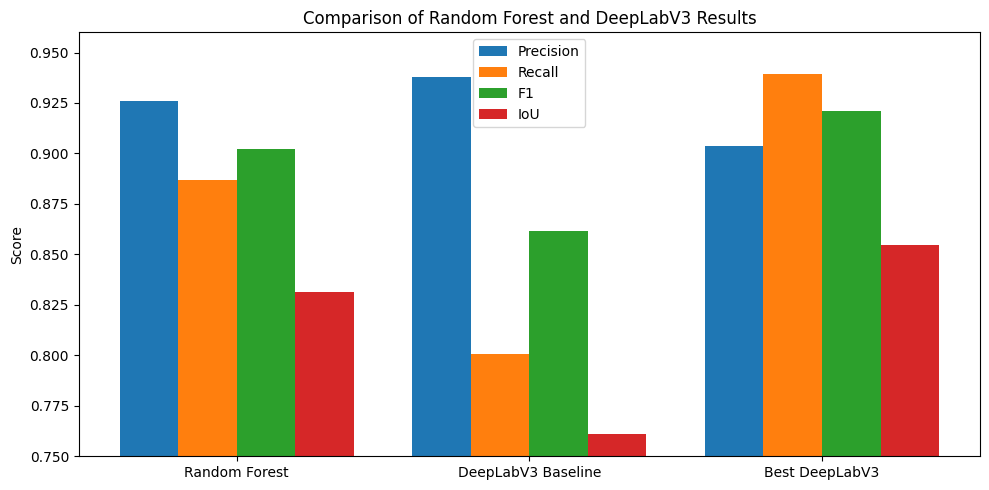

In [27]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Random Forest", "DeepLabV3 Baseline", "Best DeepLabV3"]
precision = [0.9260, 0.9380, 0.9037]
recall = [0.8869, 0.8008, 0.9393]
f1 = [0.9024, 0.8617, 0.9210]
iou = [0.8313, 0.7609, 0.8549]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 5))
plt.bar(x - 1.5*width, precision, width, label="Precision")
plt.bar(x - 0.5*width, recall, width, label="Recall")
plt.bar(x + 0.5*width, f1, width, label="F1")
plt.bar(x + 1.5*width, iou, width, label="IoU")

plt.xticks(x, models)
plt.ylim(0.75, 0.96)
plt.ylabel("Score")
plt.title("Comparison of Random Forest and DeepLabV3 Results")
plt.legend()
plt.tight_layout()
plt.show()